# AtrionNet Dataset Exploratory Analysis
This notebook explores the **Lobachevsky University Electrocardiography Database (LUDB)** entire 200 record spread.
It visualizes the raw ECG signals, extracts the precise P-wave bounding boxes from the annotations, and exposes the global class imbalance.

In [11]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define formatting for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 5)

DATA_DIR = "../data/raw/ludb/data"
if not os.path.exists(DATA_DIR):
    print(f"Data directory {DATA_DIR} not found. Please ensure LUDB is downloaded.")

### 1. Loading and Visualizing a Single Record
We will load a record, extract Lead II, and parse the annotation symbols (`(`, `p`, `)`) to find the exact boundaries of the P-waves.

In [12]:
# Choose a record ID
record_id = "1"
record_path = os.path.join(DATA_DIR, record_id)

try:
    # 1. Load Raw Signal
    record = wfdb.rdrecord(record_path)
    fs = record.fs
    print(f"Loaded Record '{record_id}': ID={record.record_name}, FS={fs}Hz, Length={record.sig_len} samples")
    
    # 2. Extract Lead II specifically (commonly used for rhythm and P-wave analysis)
    lead_idx = record.sig_name.index('ii')
    lead_ii = record.p_signal[:, lead_idx]
    
    # 3. Load Annotations dynamically trying standard leads
    annotation_found = False
    for lead in ['ii', 'v1', 'v5', 'i', 'iii', 'avf']:
        try:
            ann = wfdb.rdann(record_path, lead)
            annotation_found = True
            print(f"✅ Found annotations on Lead: {lead}")
            break
        except Exception:
            continue
            
    if not annotation_found:
        print("❌ No annotations found.")
        ann = None

except Exception as e:
    print(f"Error loading record: {e}")
    ann = None

Loaded Record '1': ID=1, FS=500Hz, Length=5000 samples
✅ Found annotations on Lead: ii


In [13]:
if ann:
    print("--- Annotation Snippet ---")
    symbol_meaning = {'(': 'Wave Onset', ')': 'Wave Offset', 'p': 'P-wave peak', 'N': 'Normal QRS peak', 't': 'T-wave peak'}
    
    for i in range(15):
        if i >= len(ann.sample): break
        sym = ann.symbol[i]
        print(f"Sample: {ann.sample[i]:<5} | Symbol: '{sym}' | Meaning: {symbol_meaning.get(sym, sym)}")

    # Extract exactly the P-waves
    p_waves = [] # List of (onset, peak, offset)
    
    i = 0
    while i < len(ann.sample):
        if ann.symbol[i] == '(' and i+2 < len(ann.sample) and ann.symbol[i+1] == 'p' and ann.symbol[i+2] == ')':
            onset = ann.sample[i]
            peak = ann.sample[i+1]
            offset = ann.sample[i+2]
            p_waves.append((onset, peak, offset))
            p_class_count += 1
            i += 3
        else:
            i += 1
            
    print(f"\n✅ Parsed {len(p_waves)} distinct P-waves for plotting.")

--- Annotation Snippet ---
Sample: 644   | Symbol: '(' | Meaning: Wave Onset
Sample: 662   | Symbol: 'N' | Meaning: Normal QRS peak
Sample: 682   | Symbol: ')' | Meaning: Wave Offset
Sample: 776   | Symbol: '(' | Meaning: Wave Onset
Sample: 843   | Symbol: 't' | Meaning: T-wave peak
Sample: 878   | Symbol: ')' | Meaning: Wave Offset
Sample: 1250  | Symbol: '(' | Meaning: Wave Onset
Sample: 1278  | Symbol: 'p' | Meaning: P-wave peak
Sample: 1302  | Symbol: ')' | Meaning: Wave Offset
Sample: 1324  | Symbol: '(' | Meaning: Wave Onset
Sample: 1342  | Symbol: 'N' | Meaning: Normal QRS peak
Sample: 1374  | Symbol: ')' | Meaning: Wave Offset
Sample: 1458  | Symbol: '(' | Meaning: Wave Onset
Sample: 1524  | Symbol: 't' | Meaning: T-wave peak
Sample: 1572  | Symbol: ')' | Meaning: Wave Offset

✅ Parsed 5 distinct P-waves for plotting.


### 2. Plotting the Ground Truth P-Wave Boundaries
The model will learn to predict exactly these highlighted bounding spans.

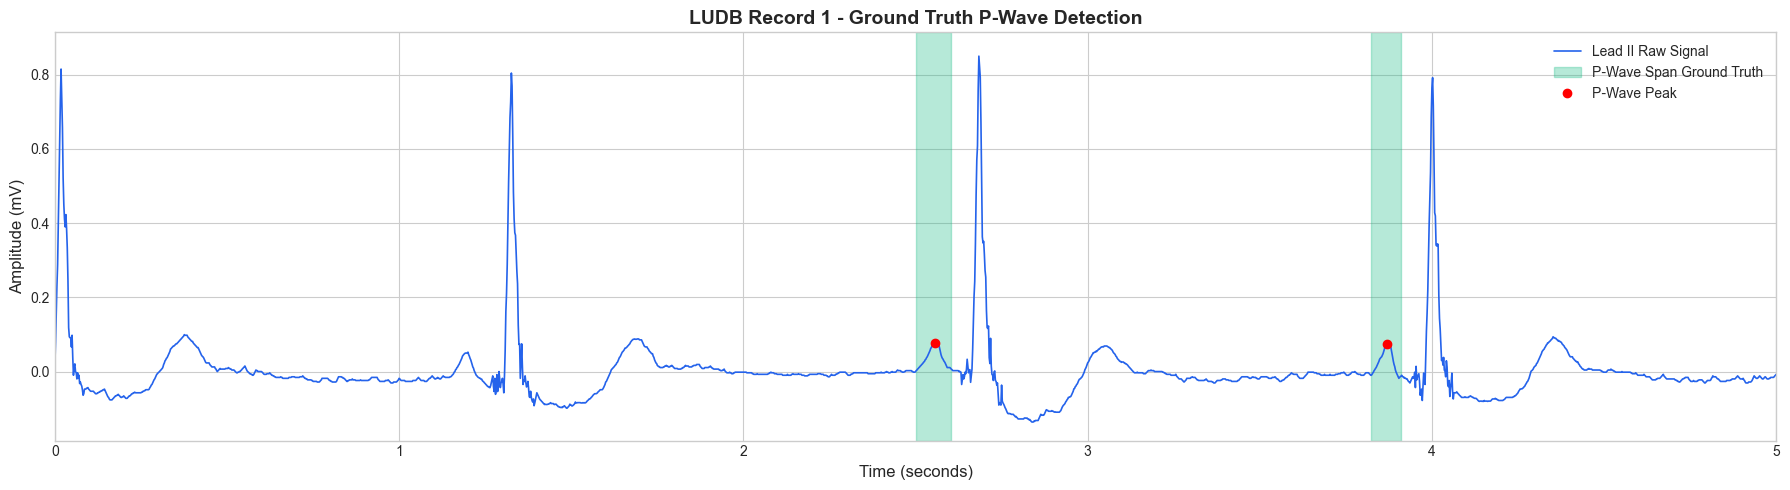

In [14]:
if ann:
    plt.figure(figsize=(18, 5))
    time_axis = np.arange(len(lead_ii)) / fs
    
    # Plot the raw ECG line
    plt.plot(time_axis, lead_ii, label='Lead II Raw Signal', color='#2563eb', linewidth=1.2)
    
    # Highlight the P-Waves
    for idx, (onset, peak, offset) in enumerate(p_waves):
        # Draw a bounding box region
        plt.axvspan(onset / fs, offset / fs, color='#10b981', alpha=0.3, 
                    label='P-Wave Span Ground Truth' if idx == 0 else "")
        # Mark the actual numerical peak
        plt.plot(peak / fs, lead_ii[peak], 'ro', markersize=6, 
                 label='P-Wave Peak' if idx == 0 else "")
        
    plt.title(f"LUDB Record {record_id} - Ground Truth P-Wave Detection", fontsize=14, fontweight='bold')
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Amplitude (mV)', fontsize=12)
    plt.xlim(0, 5) # Show first 5 seconds
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

### 3. Global Dataset Analysis (200 Records) & Class Imbalance
Iterating over all 200 LUDB records to expose the core problem of P-wave instance detection: **extreme class imbalance**. P-waves are biologically smaller and computationally less frequent than QRS structures (especially in pathological records).

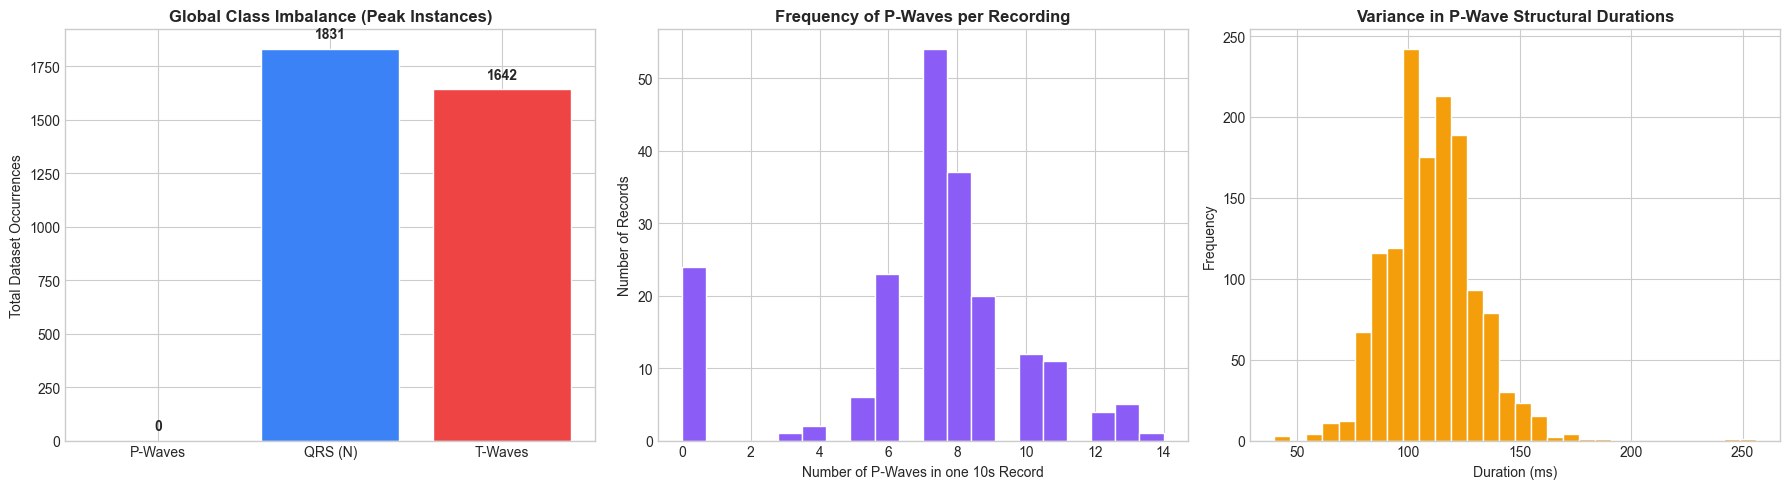


--- Global LUDB Statistics ---
✅ Extracted data from 200 independent ECG recordings.
⚠️  Imbalance Ratio: For every 100 QRS complexes, there are only 0 P-waves.
⏱  Average P-wave structural duration: 110.3 ms.


In [15]:
# Comprehensive iteration over all 200 records to expose class imbalance
p_durations = []
p_counts = []
p_class_count = 0
qrs_class_count = 0
t_class_count = 0

for rec in range(1, 201):
    r_path = os.path.join(DATA_DIR, str(rec))
    if not os.path.isfile(r_path + '.hea'): continue
        
    for lead in ['ii', 'v1', 'v2', 'v5', 'i', 'iii', 'avf']:
        try:
            temp_ann = wfdb.rdann(r_path, lead)
            
            c = 0
            i = 0
            while i < len(temp_ann.sample):
                sym = temp_ann.symbol[i]
                if sym == 'p': p_class_count += 1
                elif sym == 'N': qrs_class_count += 1
                elif sym == 't': t_class_count += 1
                
                if sym == '(' and i+2 < len(temp_ann.sample) and temp_ann.symbol[i+1] == 'p' and temp_ann.symbol[i+2] == ')':
                    dur_ms = (temp_ann.sample[i+2] - temp_ann.sample[i]) / 500 * 1000 # LUDB is 500Hz
                    p_durations.append(dur_ms)
                    c += 1
                    i += 3
                else:
                    i += 1
            p_counts.append(c)
            break
        except:
            continue

if p_counts:
    fig = plt.figure(figsize=(18, 5))
    
    # 1. Bar Chart: Extreme Class Imbalance
    ax1 = plt.subplot(1, 3, 1)
    classes = ['P-Waves', 'QRS (N)', 'T-Waves']
    counts = [p_class_count, qrs_class_count, t_class_count]
    colors = ['#10b981', '#3b82f6', '#ef4444']
    ax1.bar(classes, counts, color=colors, edgecolor='white')
    ax1.set_title('Global Class Imbalance (Peak Instances)', fontweight='bold')
    ax1.set_ylabel('Total Dataset Occurrences')
    for i, v in enumerate(counts):
        ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')
        
    # 2. Histogram: P-Waves per recording
    ax2 = plt.subplot(1, 3, 2)
    ax2.hist(p_counts, bins=20, color='#8b5cf6', edgecolor='white')
    ax2.set_title('Frequency of P-Waves per Recording', fontweight='bold')
    ax2.set_xlabel('Number of P-Waves in one 10s Record')
    ax2.set_ylabel('Number of Records')

    # 3. Histogram: Structural Durations
    ax3 = plt.subplot(1, 3, 3)
    ax3.hist(p_durations, bins=30, color='#f59e0b', edgecolor='white')
    ax3.set_title('Variance in P-Wave Structural Durations', fontweight='bold')
    ax3.set_xlabel('Duration (ms)')
    ax3.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    print("\n--- Global LUDB Statistics ---")
    print(f"✅ Extracted data from {len(p_counts)} independent ECG recordings.")
    print(f"⚠️  Imbalance Ratio: For every 100 QRS complexes, there are only {int((p_class_count/qrs_class_count)*100)} P-waves.")
    print(f"⏱  Average P-wave structural duration: {np.mean(p_durations):.1f} ms.")